# Predicción de Generación Solar con Variables Meteorológicas

Este notebook entrena un modelo de machine learning para predecir la generación de un panel solar basándose en variables climatológicas obtenidas de Open-Meteo API.

## Variables de entrada (Open-Meteo):
- `temperature_2m`: Temperatura del aire a 2m (°C)
- `relative_humidity_2m`: Humedad relativa (%)
- `wind_speed_10m`: Velocidad del viento a 10m (m/s)
- `cloud_cover`: Cobertura de nubes (%)
- `shortwave_radiation`: Radiación solar de onda corta (W/m²)

## Variable objetivo:
- `SystemProduction`: Generación del panel solar (kW)

## 1. Importar librerías

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 2. Cargar y explorar datos

In [6]:
# Cargar datos
df = pd.read_csv('datasets/clima paneles/Solar Power Plant Data.csv')

print("Forma del dataset:", df.shape)
print("\nPrimeras filas:")
df.head(10)

Forma del dataset: (8760, 8)

Primeras filas:


,Date-Hour(NMT),WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
0,01.01.2017-00:00,0.6,0,1003.8,-7.4,0.1,97,0.0
1,01.01.2017-01:00,1.7,0,1003.5,-7.4,-0.2,98,0.0
2,01.01.2017-02:00,0.6,0,1003.4,-6.7,-1.2,99,0.0
3,01.01.2017-03:00,2.4,0,1003.3,-7.2,-1.3,99,0.0
4,01.01.2017-04:00,4.0,0,1003.1,-6.3,3.6,67,0.0
5,01.01.2017-05:00,1.4,0,1003.1,-6.8,1.5,74,0.0
6,01.01.2017-06:00,1.4,0,1003.7,-7.0,0.4,79,0.0
7,01.01.2017-07:00,1.3,0,1003.9,-7.0,-0.9,81,0.0
8,01.01.2017-08:00,0.6,0,1004.3,-6.6,-1.0,77,0.0
9,01.01.2017-09:00,0.6,0,1004.8,-6.5,-2.0,81,0.0


In [7]:
# Información del dataset
print("Información del dataset:")
df.info()

print("\n" + "="*50)
print("Estadísticas descriptivas:")
df.describe()

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date-Hour(NMT)       8760 non-null   object 
 1   WindSpeed            8760 non-null   float64
 2   Sunshine             8760 non-null   int64  
 3   AirPressure          8760 non-null   float64
 4   Radiation            8760 non-null   float64
 5   AirTemperature       8760 non-null   float64
 6   RelativeAirHumidity  8760 non-null   int64  
 7   SystemProduction     8760 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 547.6+ KB

Estadísticas descriptivas:


,WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,2.639823,11.180479,1010.361781,97.538493,6.978893,76.719406,684.746071
std,1.628754,21.171295,12.793971,182.336029,7.604266,19.278996,1487.454665
min,0.000000,0.000000,965.900000,-9.300000,-12.400000,13.000000,0.000000
25%,1.400000,0.000000,1002.800000,-6.200000,0.500000,64.000000,0.000000
50%,2.300000,0.000000,1011.000000,-1.400000,6.400000,82.000000,0.000000
75%,3.600000,7.000000,1018.200000,115.600000,13.400000,93.000000,464.249950
max,10.900000,60.000000,1047.300000,899.700000,27.100000,100.000000,7701.000000


In [8]:
# Verificar valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nPorcentaje de valores nulos:")
print((df.isnull().sum() / len(df) * 100).round(2))

Valores nulos por columna:
Date-Hour(NMT)         0
WindSpeed              0
Sunshine               0
AirPressure            0
Radiation              0
AirTemperature         0
RelativeAirHumidity    0
SystemProduction       0
dtype: int64

Porcentaje de valores nulos:
Date-Hour(NMT)         0.0
WindSpeed              0.0
Sunshine               0.0
AirPressure            0.0
Radiation              0.0
AirTemperature         0.0
RelativeAirHumidity    0.0
SystemProduction       0.0
dtype: float64


Análisis de la variable 'Radiation':
  Valores positivos: 4290 (49.0%)
  Valores negativos: 4464 (51.0%)
  Valores cero: 6 (0.1%)


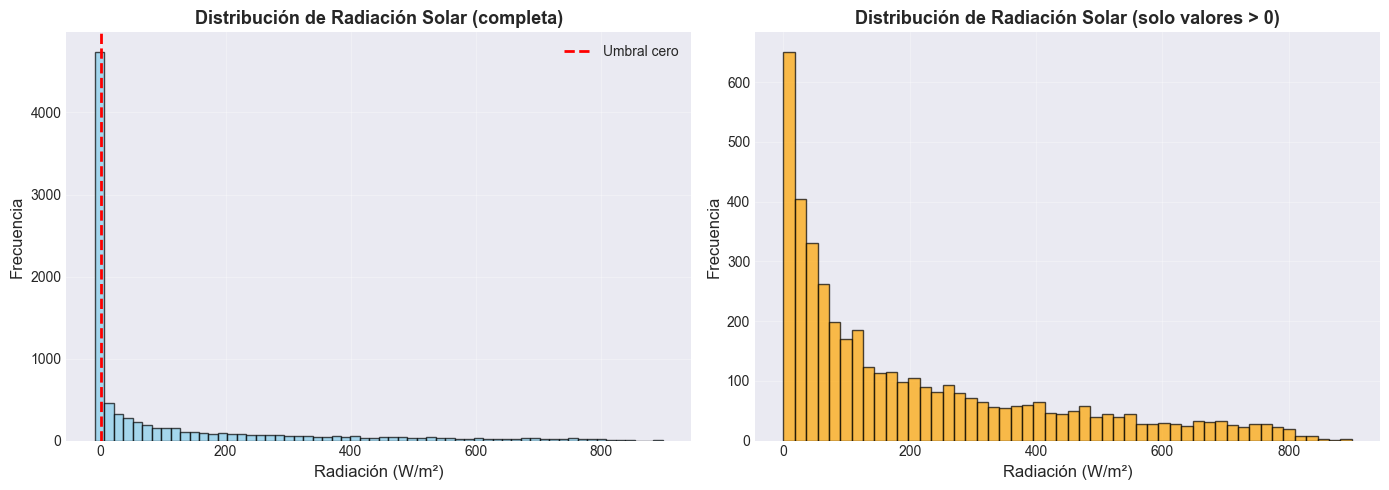


Nota: Los valores negativos (-9.3 a ~0) representan pérdida de calor radiativo nocturno.
Open-Meteo reporta 0 W/m² durante la noche, así que vamos a convertir valores negativos a 0.


In [9]:
# Analizar distribución de radiación solar
print("Análisis de la variable 'Radiation':")
print(f"  Valores positivos: {(df['Radiation'] > 0).sum()} ({(df['Radiation'] > 0).sum() / len(df) * 100:.1f}%)")
print(f"  Valores negativos: {(df['Radiation'] < 0).sum()} ({(df['Radiation'] < 0).sum() / len(df) * 100:.1f}%)")
print(f"  Valores cero: {(df['Radiation'] == 0).sum()} ({(df['Radiation'] == 0).sum() / len(df) * 100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma completo
axes[0].hist(df['Radiation'], bins=60, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(x=0, color='r', linestyle='--', lw=2, label='Umbral cero')
axes[0].set_xlabel('Radiación (W/m²)', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_title('Distribución de Radiación Solar (completa)', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histograma solo valores positivos
positive_radiation = df[df['Radiation'] > 0]['Radiation']
axes[1].hist(positive_radiation, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Radiación (W/m²)', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)
axes[1].set_title('Distribución de Radiación Solar (solo valores > 0)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nNota: Los valores negativos (-9.3 a ~0) representan pérdida de calor radiativo nocturno.")
print(f"Open-Meteo reporta 0 W/m² durante la noche, así que vamos a convertir valores negativos a 0.")

## 3. Preprocesamiento y Feature Engineering

In [10]:
# Crear copia para trabajar
data = df.copy()

# Parsear fecha y hora
data['DateTime'] = pd.to_datetime(data['Date-Hour(NMT)'], format='%d.%m.%Y-%H:%M')
data['Hour'] = data['DateTime'].dt.hour
data['Month'] = data['DateTime'].dt.month
data['DayOfYear'] = data['DateTime'].dt.dayofyear

# Renombrar columnas para que coincidan con Open-Meteo
data = data.rename(columns={
    'AirTemperature': 'temperature_2m',
    'RelativeAirHumidity': 'relative_humidity_2m',
    'WindSpeed': 'wind_speed_10m',
    'Radiation': 'shortwave_radiation_raw',
    'Sunshine': 'sunshine_minutes'
})

# IMPORTANTE: Corregir radiación negativa (valores nocturnos)
# Open-Meteo reporta 0 W/m² durante la noche, no valores negativos
# Los valores negativos representan pérdida de calor radiativo nocturno
data['shortwave_radiation'] = data['shortwave_radiation_raw'].clip(lower=0)

print(f"Valores de radiación corregidos:")
print(f"  Original: min={data['shortwave_radiation_raw'].min():.2f}, max={data['shortwave_radiation_raw'].max():.2f}")
print(f"  Corregido: min={data['shortwave_radiation'].min():.2f}, max={data['shortwave_radiation'].max():.2f}")

# Calcular cloud_cover a partir de sunshine
# Sunshine va de 0-60 minutos por hora (no porcentaje)
# Si sunshine = 60 minutos → 100% sol → cloud_cover = 0%
# Si sunshine = 0 minutos → 0% sol → cloud_cover = 100%
data['sunshine_percent'] = (data['sunshine_minutes'] / 60) * 100
data['cloud_cover'] = 100 - data['sunshine_percent']

print(f"\nRango de cloud_cover: {data['cloud_cover'].min():.1f}% - {data['cloud_cover'].max():.1f}%")

# Features de ciclo temporal (sen/cos para capturar ciclicidad)
data['hour_sin'] = np.sin(2 * np.pi * data['Hour'] / 24)
data['hour_cos'] = np.cos(2 * np.pi * data['Hour'] / 24)
data['month_sin'] = np.sin(2 * np.pi * data['Month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['Month'] / 12)

print("\nNuevas columnas creadas:")
print(data.columns.tolist())

Valores de radiación corregidos:
  Original: min=-9.30, max=899.70
  Corregido: min=0.00, max=899.70

Rango de cloud_cover: 0.0% - 100.0%

Nuevas columnas creadas:
['Date-Hour(NMT)', 'wind_speed_10m', 'sunshine_minutes', 'AirPressure', 'shortwave_radiation_raw', 'temperature_2m', 'relative_humidity_2m', 'SystemProduction', 'DateTime', 'Hour', 'Month', 'DayOfYear', 'shortwave_radiation', 'sunshine_percent', 'cloud_cover', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']


In [11]:
# Seleccionar features que coinciden con Open-Meteo + features temporales
feature_columns = [
    'temperature_2m',
    'relative_humidity_2m',
    'wind_speed_10m',
    'cloud_cover',
    'shortwave_radiation',
    'hour_sin',
    'hour_cos',
    'month_sin',
    'month_cos'
]

target_column = 'SystemProduction'

# Eliminar filas con valores nulos
data_clean = data[feature_columns + [target_column]].dropna()

print(f"Registros después de limpieza: {len(data_clean)} (eliminados: {len(data) - len(data_clean)})")
print(f"\nDistribución de producción:")
print(data_clean[target_column].describe())

Registros después de limpieza: 8760 (eliminados: 0)

Distribución de producción:
count    8760.000000
mean      684.746071
std      1487.454665
min         0.000000
25%         0.000000
50%         0.000000
75%       464.249950
max      7701.000000
Name: SystemProduction, dtype: float64


## 4. Análisis Exploratorio de Datos (EDA)

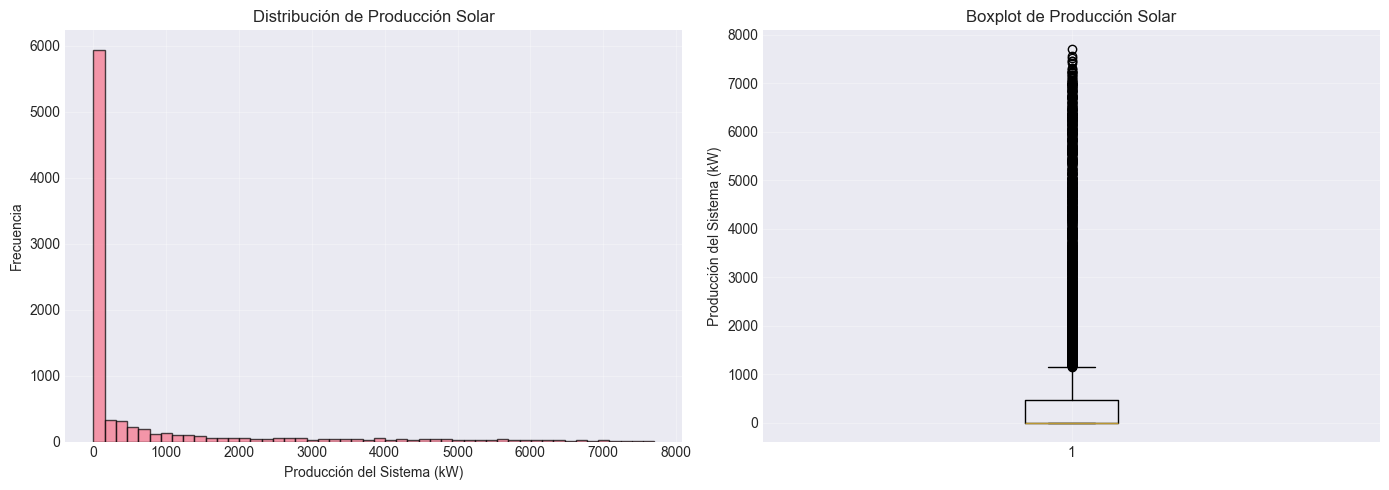

Producción promedio: 684.75 kW
Producción máxima: 7701.00 kW
% de registros con producción = 0: 62.58%


In [12]:
# Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(data_clean[target_column], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Producción del Sistema (kW)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Producción Solar')
axes[0].grid(True, alpha=0.3)

# Boxplot
axes[1].boxplot(data_clean[target_column])
axes[1].set_ylabel('Producción del Sistema (kW)')
axes[1].set_title('Boxplot de Producción Solar')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Producción promedio: {data_clean[target_column].mean():.2f} kW")
print(f"Producción máxima: {data_clean[target_column].max():.2f} kW")
print(f"% de registros con producción = 0: {(data_clean[target_column] == 0).sum() / len(data_clean) * 100:.2f}%")

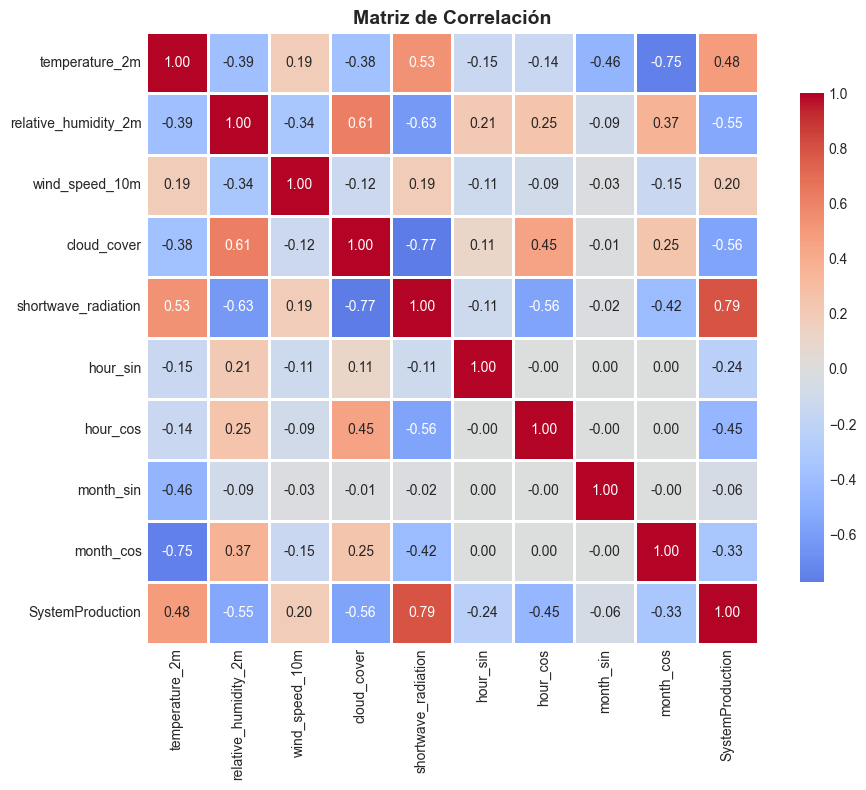


Correlación con SystemProduction:
SystemProduction        1.000000
shortwave_radiation     0.785433
temperature_2m          0.480407
wind_speed_10m          0.195650
month_sin              -0.055484
hour_sin               -0.239603
month_cos              -0.330808
hour_cos               -0.445258
relative_humidity_2m   -0.545252
cloud_cover            -0.564228
Name: SystemProduction, dtype: float64


In [13]:
# Correlación entre variables
plt.figure(figsize=(10, 8))
correlation_matrix = data_clean.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelación con SystemProduction:")
print(correlation_matrix[target_column].sort_values(ascending=False))

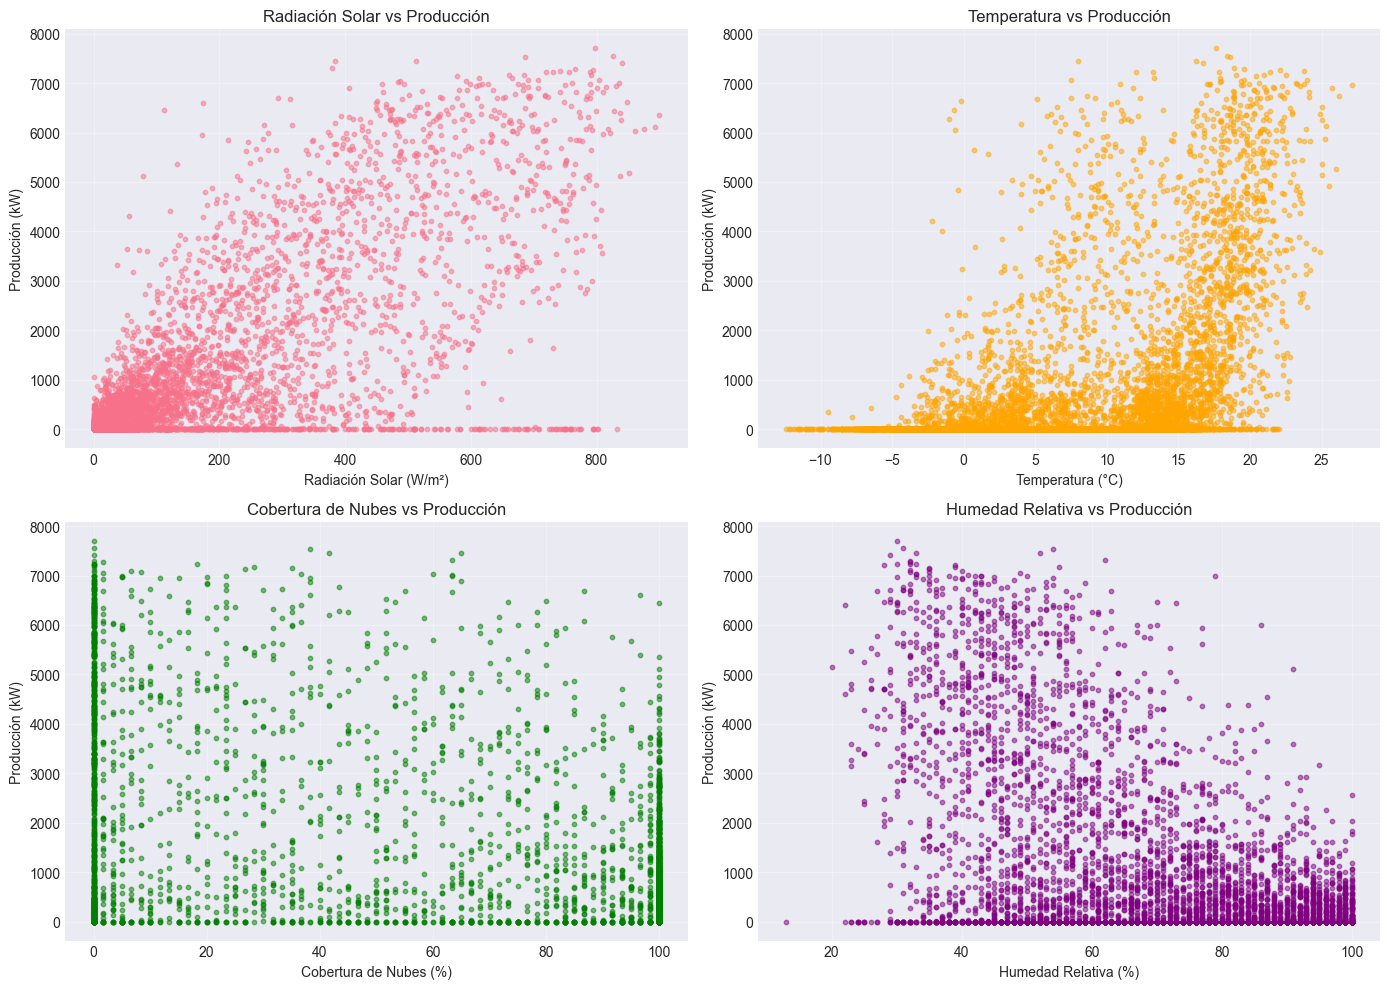

In [14]:
# Relación entre radiación solar y producción
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Radiación vs Producción
axes[0, 0].scatter(data_clean['shortwave_radiation'], data_clean[target_column], alpha=0.5, s=10)
axes[0, 0].set_xlabel('Radiación Solar (W/m²)')
axes[0, 0].set_ylabel('Producción (kW)')
axes[0, 0].set_title('Radiación Solar vs Producción')
axes[0, 0].grid(True, alpha=0.3)

# Temperatura vs Producción
axes[0, 1].scatter(data_clean['temperature_2m'], data_clean[target_column], alpha=0.5, s=10, color='orange')
axes[0, 1].set_xlabel('Temperatura (°C)')
axes[0, 1].set_ylabel('Producción (kW)')
axes[0, 1].set_title('Temperatura vs Producción')
axes[0, 1].grid(True, alpha=0.3)

# Cloud Cover vs Producción
axes[1, 0].scatter(data_clean['cloud_cover'], data_clean[target_column], alpha=0.5, s=10, color='green')
axes[1, 0].set_xlabel('Cobertura de Nubes (%)')
axes[1, 0].set_ylabel('Producción (kW)')
axes[1, 0].set_title('Cobertura de Nubes vs Producción')
axes[1, 0].grid(True, alpha=0.3)

# Humedad vs Producción
axes[1, 1].scatter(data_clean['relative_humidity_2m'], data_clean[target_column], alpha=0.5, s=10, color='purple')
axes[1, 1].set_xlabel('Humedad Relativa (%)')
axes[1, 1].set_ylabel('Producción (kW)')
axes[1, 1].set_title('Humedad Relativa vs Producción')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

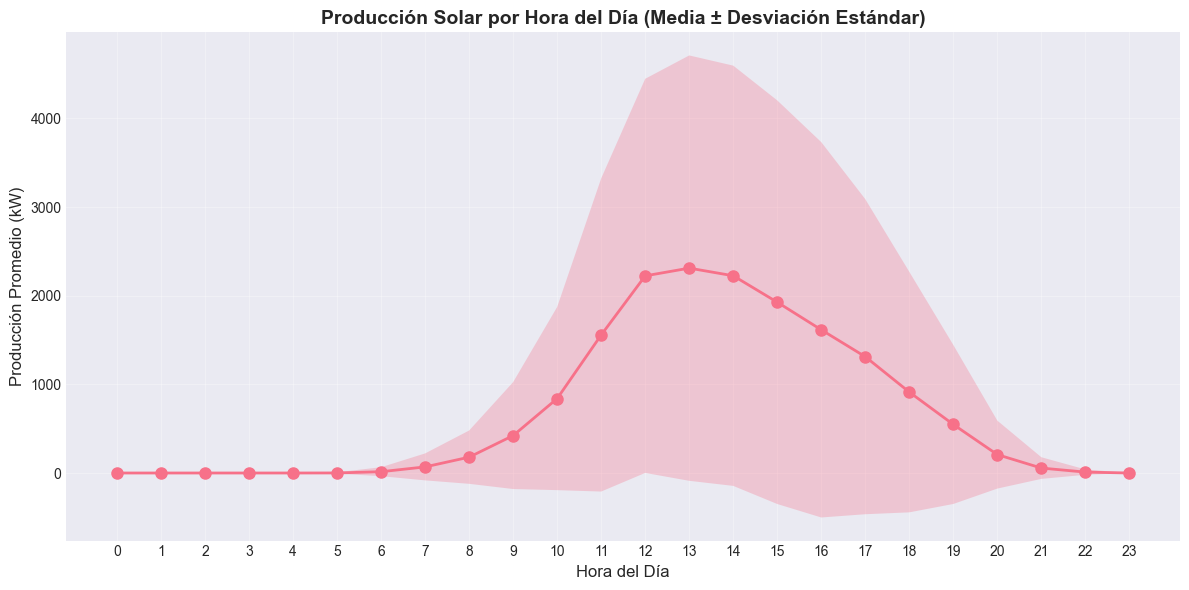

In [15]:
# Producción promedio por hora del día
data_with_hour = data_clean.copy()
data_with_hour['Hour'] = data.loc[data_clean.index, 'Hour']

hourly_production = data_with_hour.groupby('Hour')[target_column].agg(['mean', 'std', 'count'])

plt.figure(figsize=(12, 6))
plt.plot(hourly_production.index, hourly_production['mean'], marker='o', linewidth=2, markersize=8)
plt.fill_between(hourly_production.index, 
                 hourly_production['mean'] - hourly_production['std'],
                 hourly_production['mean'] + hourly_production['std'],
                 alpha=0.3)
plt.xlabel('Hora del Día', fontsize=12)
plt.ylabel('Producción Promedio (kW)', fontsize=12)
plt.title('Producción Solar por Hora del Día (Media ± Desviación Estándar)', fontsize=14, fontweight='bold')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Preparar datos para entrenamiento

In [16]:
# Separar features y target
X = data_clean[feature_columns]
y = data_clean[target_column]

# Split train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} registros")
print(f"Conjunto de prueba: {X_test.shape[0]} registros")
print(f"\nFeatures utilizadas: {len(feature_columns)}")
print(feature_columns)

Conjunto de entrenamiento: 7008 registros
Conjunto de prueba: 1752 registros

Features utilizadas: 9
['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'cloud_cover', 'shortwave_radiation', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']


In [17]:
# Escalar features (importante para algunos modelos)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features escaladas con StandardScaler")
print(f"Media de features escaladas: {X_train_scaled.mean(axis=0).round(3)}")
print(f"Desviación estándar de features escaladas: {X_train_scaled.std(axis=0).round(3)}")

Features escaladas con StandardScaler
Media de features escaladas: [ 0.  0.  0.  0.  0.  0. -0. -0.  0.]
Desviación estándar de features escaladas: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 6. Entrenar y comparar modelos

In [18]:
# Función para evaluar modelos
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Entrena y evalúa un modelo de regresión.
    """
    # Entrenar
    model.fit(X_train, y_train)
    
    # Predicciones
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Métricas de entrenamiento
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    
    # Métricas de prueba
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, 
                                 scoring='neg_root_mean_squared_error')
    cv_rmse = -cv_scores.mean()
    
    results = {
        'model': model,
        'model_name': model_name,
        'train_rmse': train_rmse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'cv_rmse': cv_rmse,
        'predictions': y_test_pred
    }
    
    print(f"\n{'='*60}")
    print(f"Modelo: {model_name}")
    print(f"{'='*60}")
    print(f"\nEntrenamiento:")
    print(f"  RMSE: {train_rmse:.4f} kW")
    print(f"  MAE:  {train_mae:.4f} kW")
    print(f"  R²:   {train_r2:.4f}")
    print(f"\nPrueba:")
    print(f"  RMSE: {test_rmse:.4f} kW")
    print(f"  MAE:  {test_mae:.4f} kW")
    print(f"  R²:   {test_r2:.4f}")
    print(f"\nCross-Validation (5-fold):")
    print(f"  RMSE: {cv_rmse:.4f} kW")
    
    return results

### 6.1 Linear Regression

In [19]:
lr_model = LinearRegression()
lr_results = evaluate_model(lr_model, X_train_scaled, X_test_scaled, 
                            y_train, y_test, "Linear Regression")


Modelo: Linear Regression

Entrenamiento:
  RMSE: 876.5510 kW
  MAE:  503.3148 kW
  R²:   0.6615

Prueba:
  RMSE: 857.2170 kW
  MAE:  490.4716 kW
  R²:   0.6286

Cross-Validation (5-fold):
  RMSE: 878.3692 kW


### 6.2 Ridge Regression

In [20]:
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_results = evaluate_model(ridge_model, X_train_scaled, X_test_scaled, 
                               y_train, y_test, "Ridge Regression")


Modelo: Ridge Regression

Entrenamiento:
  RMSE: 876.5510 kW
  MAE:  503.3263 kW
  R²:   0.6615

Prueba:
  RMSE: 857.2040 kW
  MAE:  490.4664 kW
  R²:   0.6286

Cross-Validation (5-fold):
  RMSE: 878.3689 kW


### 6.3 Random Forest

In [21]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_results = evaluate_model(rf_model, X_train, X_test, 
                            y_train, y_test, "Random Forest")


Modelo: Random Forest

Entrenamiento:
  RMSE: 298.6612 kW
  MAE:  121.4781 kW
  R²:   0.9607

Prueba:
  RMSE: 536.8594 kW
  MAE:  229.1210 kW
  R²:   0.8543

Cross-Validation (5-fold):
  RMSE: 600.7511 kW


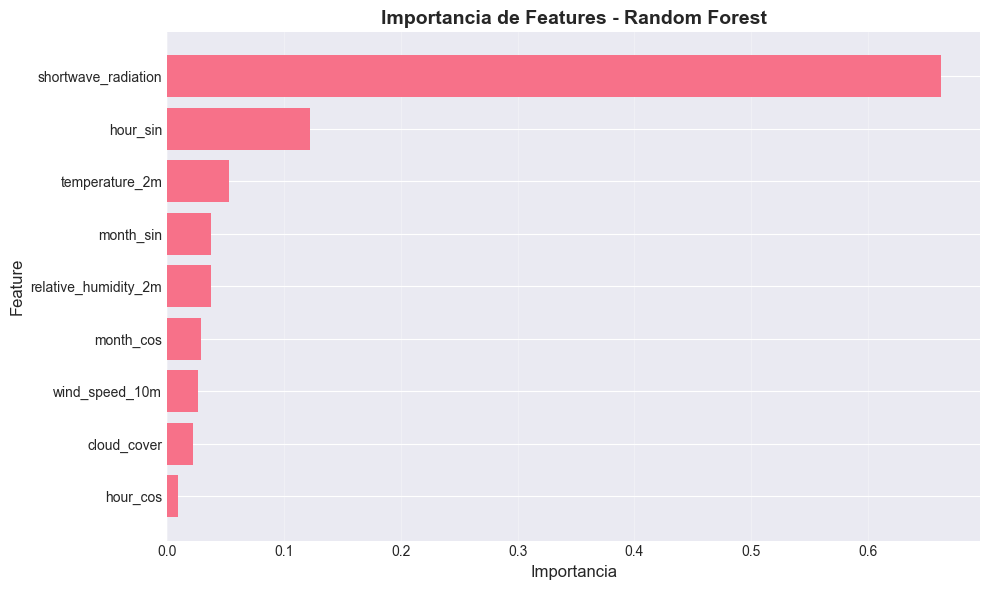


Importancia de features:
             feature  importance
 shortwave_radiation    0.662577
            hour_sin    0.122602
      temperature_2m    0.053058
           month_sin    0.037920
relative_humidity_2m    0.037335
           month_cos    0.028865
      wind_speed_10m    0.026284
         cloud_cover    0.021981
            hour_cos    0.009378


In [22]:
# Importancia de features (Random Forest)
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Importancia de Features - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nImportancia de features:")
print(feature_importance.to_string(index=False))

### 6.4 Gradient Boosting

In [23]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
gb_results = evaluate_model(gb_model, X_train, X_test, 
                            y_train, y_test, "Gradient Boosting")


Modelo: Gradient Boosting

Entrenamiento:
  RMSE: 387.0483 kW
  MAE:  178.0482 kW
  R²:   0.9340

Prueba:
  RMSE: 542.5240 kW
  MAE:  237.7808 kW
  R²:   0.8512

Cross-Validation (5-fold):
  RMSE: 597.4043 kW


### 6.5 Comparación de modelos

In [24]:
# Tabla comparativa
all_results = [lr_results, ridge_results, rf_results, gb_results]

comparison_df = pd.DataFrame([
    {
        'Modelo': r['model_name'],
        'Train RMSE': r['train_rmse'],
        'Test RMSE': r['test_rmse'],
        'Train MAE': r['train_mae'],
        'Test MAE': r['test_mae'],
        'Train R²': r['train_r2'],
        'Test R²': r['test_r2'],
        'CV RMSE': r['cv_rmse']
    }
    for r in all_results
])

print("\n" + "="*100)
print("COMPARACIÓN DE MODELOS")
print("="*100)
print(comparison_df.to_string(index=False))

# Identificar mejor modelo (menor Test RMSE)
best_idx = comparison_df['Test RMSE'].idxmin()
best_model_results = all_results[best_idx]

print(f"\n{'='*100}")
print(f"MEJOR MODELO: {best_model_results['model_name']}")
print(f"Test RMSE: {best_model_results['test_rmse']:.4f} kW")
print(f"Test R²: {best_model_results['test_r2']:.4f}")
print(f"{'='*100}")


COMPARACIÓN DE MODELOS
           Modelo  Train RMSE  Test RMSE  Train MAE   Test MAE  Train R²  Test R²    CV RMSE
Linear Regression  876.550962 857.217013 503.314756 490.471570  0.661518 0.628588 878.369153
 Ridge Regression  876.551042 857.204001 503.326285 490.466351  0.661518 0.628599 878.368904
    Random Forest  298.661178 536.859394 121.478102 229.120956  0.960705 0.854321 600.751088
Gradient Boosting  387.048276 542.524047 178.048224 237.780832  0.934005 0.851231 597.404297

MEJOR MODELO: Random Forest
Test RMSE: 536.8594 kW
Test R²: 0.8543


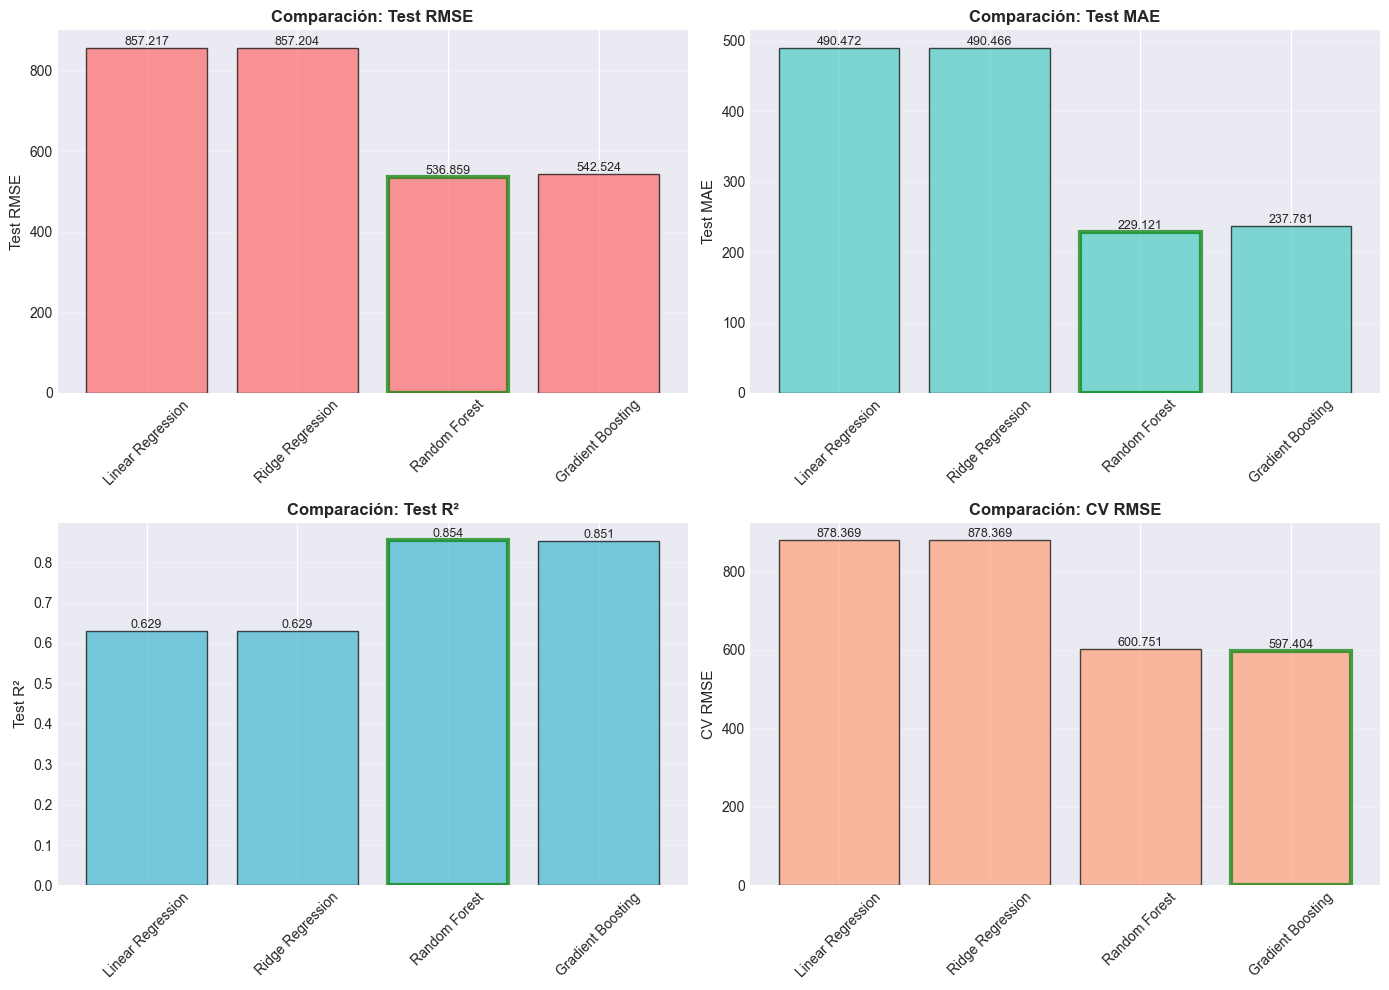

In [25]:
# Visualización comparativa
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Test RMSE', 'Test MAE', 'Test R²', 'CV RMSE']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for idx, (ax, metric, color) in enumerate(zip(axes.flat, metrics, colors)):
    values = comparison_df[metric]
    bars = ax.bar(comparison_df['Modelo'], values, color=color, alpha=0.7, edgecolor='black')
    
    # Destacar mejor valor
    if metric == 'Test R²':
        best_idx_metric = values.idxmax()
    else:
        best_idx_metric = values.idxmin()
    bars[best_idx_metric].set_edgecolor('green')
    bars[best_idx_metric].set_linewidth(3)
    
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f'Comparación: {metric}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=45)
    
    # Añadir valores sobre las barras
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Análisis de predicciones del mejor modelo

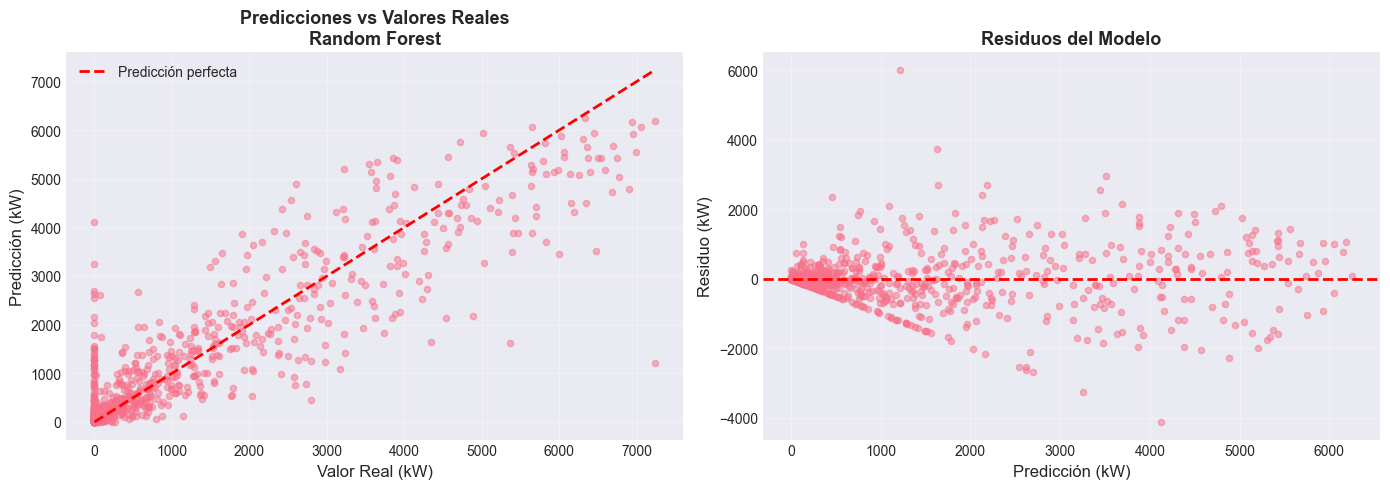


Estadísticas de residuos:
Media: -7.0856 kW
Desviación estándar: 536.9659 kW
Mínimo: -4118.8169 kW
Máximo: 6010.0352 kW


In [26]:
# Predicciones vs valores reales
y_pred_best = best_model_results['predictions']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, y_pred_best, alpha=0.5, s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Predicción perfecta')
axes[0].set_xlabel('Valor Real (kW)', fontsize=12)
axes[0].set_ylabel('Predicción (kW)', fontsize=12)
axes[0].set_title(f'Predicciones vs Valores Reales\n{best_model_results["model_name"]}', 
                  fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuos
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.5, s=20)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicción (kW)', fontsize=12)
axes[1].set_ylabel('Residuo (kW)', fontsize=12)
axes[1].set_title('Residuos del Modelo', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nEstadísticas de residuos:")
print(f"Media: {residuals.mean():.4f} kW")
print(f"Desviación estándar: {residuals.std():.4f} kW")
print(f"Mínimo: {residuals.min():.4f} kW")
print(f"Máximo: {residuals.max():.4f} kW")

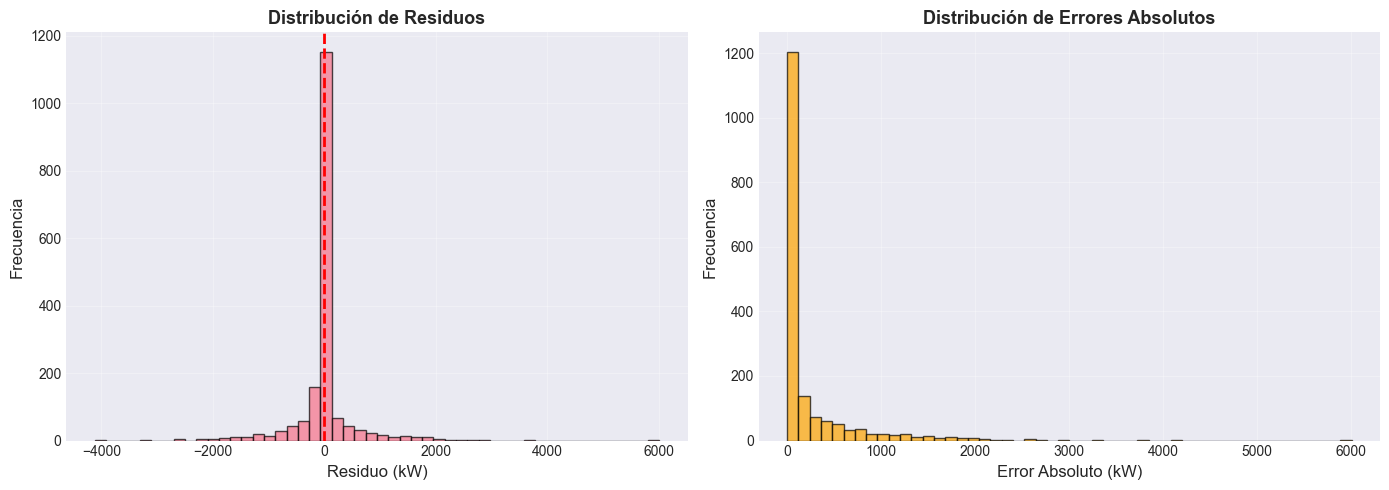


Percentiles de error absoluto:
  50%: 4.2299 kW
  75%: 209.4798 kW
  90%: 772.5983 kW
  95%: 1285.6703 kW
  99%: 2101.1991 kW


In [27]:
# Distribución de errores
errors = np.abs(residuals)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de residuos
axes[0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Residuo (kW)', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_title('Distribución de Residuos', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Histograma de errores absolutos
axes[1].hist(errors, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Error Absoluto (kW)', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)
axes[1].set_title('Distribución de Errores Absolutos', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Percentiles de error
print("\nPercentiles de error absoluto:")
for p in [50, 75, 90, 95, 99]:
    print(f"  {p}%: {np.percentile(errors, p):.4f} kW")

## 8. Guardar el mejor modelo

In [28]:
# Guardar modelo y scaler
model_to_save = best_model_results['model']
model_name = best_model_results['model_name'].replace(' ', '_').lower()

# Guardar modelo
model_path = f'../models/solar_production_{model_name}.pkl'
joblib.dump(model_to_save, model_path)
print(f"✓ Modelo guardado en: {model_path}")

# Guardar scaler (si el modelo lo necesita)
if model_name in ['linear_regression', 'ridge_regression']:
    scaler_path = f'../models/scaler_{model_name}.pkl'
    joblib.dump(scaler, scaler_path)
    print(f"✓ Scaler guardado en: {scaler_path}")

# Guardar metadata del modelo
metadata = {
    'model_name': best_model_results['model_name'],
    'train_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'features': feature_columns,
    'test_rmse': best_model_results['test_rmse'],
    'test_mae': best_model_results['test_mae'],
    'test_r2': best_model_results['test_r2'],
    'cv_rmse': best_model_results['cv_rmse'],
    'training_samples': len(X_train),
    'test_samples': len(X_test),
    'requires_scaling': model_name in ['linear_regression', 'ridge_regression']
}

metadata_path = f'../models/metadata_{model_name}.json'
import json
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Metadata guardada en: {metadata_path}")

print("\n" + "="*60)
print("MODELO GUARDADO EXITOSAMENTE")
print("="*60)
print(f"Modelo: {best_model_results['model_name']}")
print(f"Test RMSE: {best_model_results['test_rmse']:.4f} kW")
print(f"Test R²: {best_model_results['test_r2']:.4f}")
print(f"Features: {len(feature_columns)}")

✓ Modelo guardado en: ../models/solar_production_random_forest.pkl
✓ Metadata guardada en: ../models/metadata_random_forest.json

MODELO GUARDADO EXITOSAMENTE
Modelo: Random Forest
Test RMSE: 536.8594 kW
Test R²: 0.8543
Features: 9


## 9. Ejemplo de uso del modelo guardado

In [29]:
# Cargar modelo y hacer predicción de ejemplo
loaded_model = joblib.load(model_path)

# Ejemplo: condiciones meteorológicas típicas al mediodía en Cuba
ejemplo_input = pd.DataFrame([{
    'temperature_2m': 28.0,           # 28°C
    'relative_humidity_2m': 65.0,      # 65%
    'wind_speed_10m': 3.5,             # 3.5 m/s
    'cloud_cover': 20.0,               # 20% nublado
    'shortwave_radiation': 800.0,      # 800 W/m²
    'hour_sin': np.sin(2 * np.pi * 13 / 24),  # 13:00
    'hour_cos': np.cos(2 * np.pi * 13 / 24),
    'month_sin': np.sin(2 * np.pi * 6 / 12),  # Junio
    'month_cos': np.cos(2 * np.pi * 6 / 12)
}])

# Si el modelo requiere escalado, aplicarlo
if metadata['requires_scaling']:
    loaded_scaler = joblib.load(scaler_path)
    ejemplo_input_scaled = loaded_scaler.transform(ejemplo_input)
    prediccion = loaded_model.predict(ejemplo_input_scaled)[0]
else:
    prediccion = loaded_model.predict(ejemplo_input)[0]

print("\n" + "="*60)
print("EJEMPLO DE PREDICCIÓN")
print("="*60)
print("\nCondiciones meteorológicas:")
print(f"  Temperatura: {ejemplo_input['temperature_2m'].values[0]:.1f}°C")
print(f"  Humedad relativa: {ejemplo_input['relative_humidity_2m'].values[0]:.1f}%")
print(f"  Velocidad del viento: {ejemplo_input['wind_speed_10m'].values[0]:.1f} m/s")
print(f"  Cobertura de nubes: {ejemplo_input['cloud_cover'].values[0]:.1f}%")
print(f"  Radiación solar: {ejemplo_input['shortwave_radiation'].values[0]:.1f} W/m²")
print(f"  Hora: 13:00")
print(f"  Mes: Junio")
print(f"\n✓ Predicción de producción solar: {prediccion:.2f} kW")


EJEMPLO DE PREDICCIÓN

Condiciones meteorológicas:
  Temperatura: 28.0°C
  Humedad relativa: 65.0%
  Velocidad del viento: 3.5 m/s
  Cobertura de nubes: 20.0%
  Radiación solar: 800.0 W/m²
  Hora: 13:00
  Mes: Junio

✓ Predicción de producción solar: 4869.82 kW


## 10. Conclusiones

Este notebook ha entrenado y evaluado múltiples modelos de machine learning para predecir la generación de paneles solares basándose en variables meteorológicas.

### Hallazgos clave:
1. **Radiación solar** es el predictor más importante para la generación
2. **Hora del día** (features cíclicas) captura patrones temporales
3. **Cobertura de nubes** tiene correlación negativa con la producción
4. Los modelos de ensemble (Random Forest, Gradient Boosting) generalmente superan a los modelos lineales

### Próximos pasos sugeridos:
- Integrar el modelo en el backend para predicciones en tiempo real
- Implementar reentrenamiento periódico con nuevos datos
- Añadir más features (ángulo solar, estacionalidad, degradación de paneles)
- Explorar modelos de deep learning (LSTM, Transformers) para series temporales
- Calibrar el modelo con datos reales del sistema en La Habana